# Predic GRF forces on walking Polymander

In [5]:
import pickle

from polymander.experiment_loader import LoadData
from polymander.signal_processing import *
from polymander.visualization import *

In [3]:
# ------------------------- Load data ------------------------------------
# Walking polymander for prediction
poly_walking_FL = LoadData()
poly_walking_FL.load_polymander_data(dir_name=f'../data/logs_polymander/walking/no_ground_truth')
poly_walking_FL.load_force_plates_data(dir_name=f'../data/logs_force_plates/walking/FL', log_name='exp1')
print(f'{len(poly_walking_FL.list_polymander)} files in list_polymander')
print(f'{len(poly_walking_FL.list_force_plates)} files in list_force_plate')

------------------------ load data -------------------------
Folder ../data/logs_polymander/walking/no_ground_truth has been loaded
File exp1.txt in folder ../data/logs_force_plates/walking/FL has been loaded
4 files in list_polymander
1 files in list_force_plate


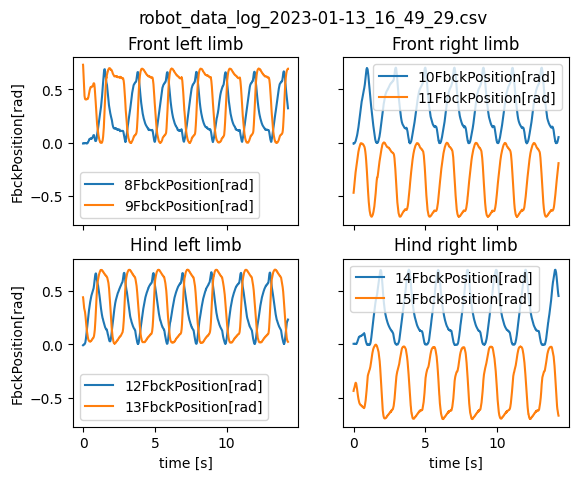

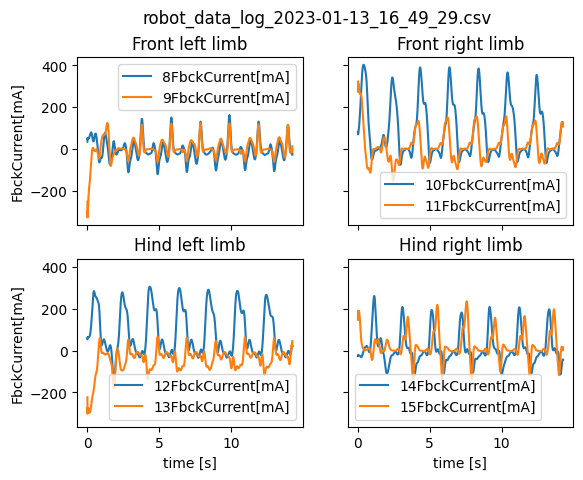

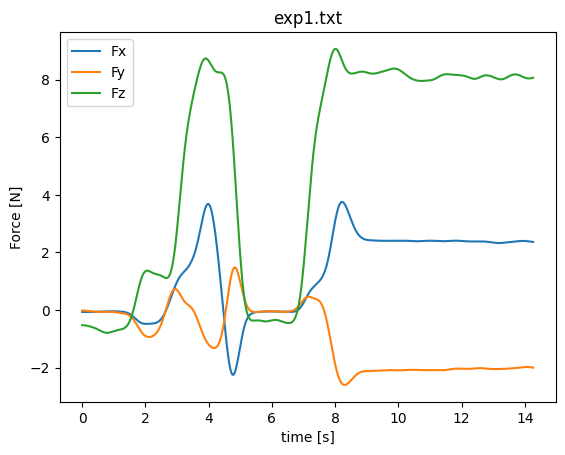

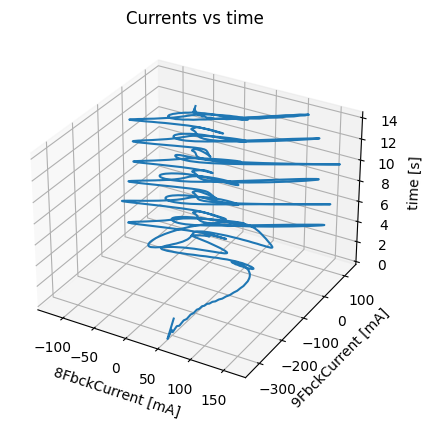

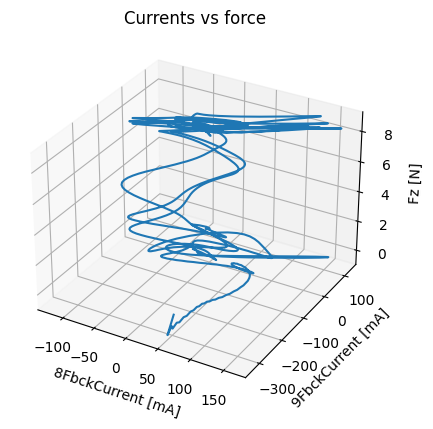

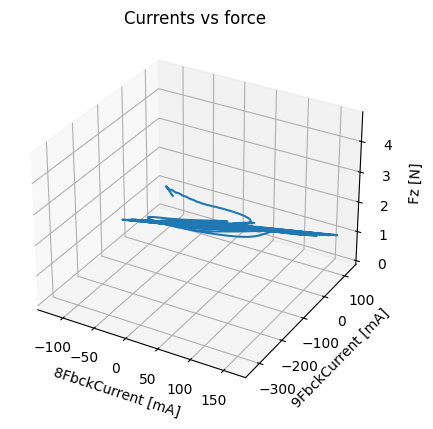

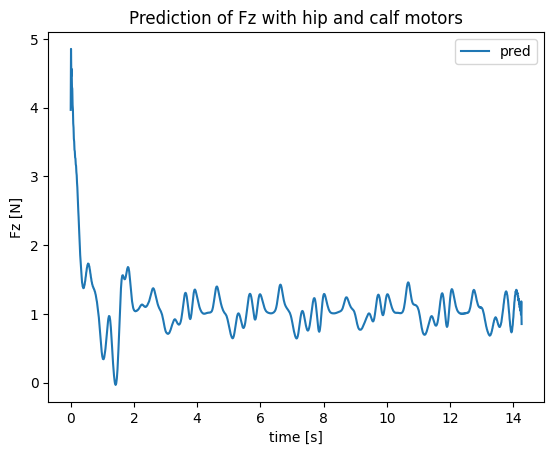

In [ ]:
# ------------------------ Feature engineering ----------------------------
for (i, j) in zip(poly_walking_FL.list_polymander, poly_walking_FL.list_force_plates):
    # Plot fbck positions
    i.plot_fbck_position(i.t_s, i.fbck_position_data)

    # Filtering
    fbck_current_filtered = filtering_signal(i.fbck_current_data, 10)
    Fxyz_filtered = filtering_signal(j.Fxyz, 20)

    # Resampling polymander from 166 Hz to 100 Hz
    # (careful the t_s_poly_resampled is not relevant since period of polymander is not reliable)
    t_s_poly_resampled, fbck_current_resampled = resample_signal(fbck_current_filtered, i.t_s, j.t_s)

    # Cut force plate signal
    t_s_final = cut_time(j.t_s, 0, len(t_s_poly_resampled))
    Fxyz_final = cut_signal(Fxyz_filtered, 0, len(t_s_poly_resampled))
    fbck_current_final = fbck_current_resampled

    # Plot final fbck current and forces
    i.plot_fbck_current(t_s_final, fbck_current_final)
    j.plot_forces(t_s_final, Fxyz_final)

    plot_3d_curents_time(t_s_final, fbck_current_final[:, 8], fbck_current_final[:, 9])
    plot_3d_currents_force(Fxyz_final[:, 2], fbck_current_final[:, 8], fbck_current_final[:, 9])

    # Store data in X and y
    X_test = fbck_current_final[:, 8:10]
    y_test = Fxyz_final[:, 2]

    # ------------------------------- Load model-------------------------
    mlr = pickle.load(open('../models/mlr.pkl', 'rb'))

    # -------------------------- Prediction of Fz for FL limb of walking polymander ---------------
    y_pred = mlr.predict(X_test)

    plot_3d_currents_force(y_pred, fbck_current_final[:, 8], fbck_current_final[:, 9])

    # Plot prediction of Fz when polymander is walking
    fig, ax = plt.subplots()
    ax.set_title('Prediction of Fz with hip and calf motors')
    #ax.plot(t_s_final, y_test, label='true value')
    ax.plot(t_s_final, y_pred, label='pred')
    ax.set(xlabel='time [s]', ylabel='Fz [N]')
    ax.legend()

plt.show()
